In [8]:
import pandas as pd
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [9]:
print('train has {} rows and {} columns'.format(*train.shape))
print('test has {} rows and {} columns'.format(*test.shape))
print(train.info())

train has 891 rows and 12 columns
test has 418 rows and 11 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [10]:
# Missing value processing
print(f"{len(train)} rows")  # 891 rows
# 1- Missing Values
# option 1
# You only have two passengers without it. This is bearable
train = train.dropna(subset=["Embarked"])  # 889 rows
print(f"{len(train)} rows after dropna of Embarked colum")
# option 2
# You only have very few information about the cabin, let's drop it
train = train.drop("Cabin", axis=1)
print(f"{len(train)} rows after drop Cabin colum")  # 889 rows
# option 3
# The age misses quite a few times. But intuition
# says it might be important for someone's chance to survive.
mean = train["Age"].mean()
train["Age"] = train["Age"].fillna(mean)

891 rows
889 rows after dropna of Embarked colum
889 rows after drop Cabin colum


In [11]:
# 2- Identifiers
print('There are {} different (unique) PassengerIds in the data'
.format(train["PassengerId"].nunique()))

print('There are {} different (unique) names in the data'
.format(train["Name"].nunique()))

print('There are {} different (unique) ticket numbers in the data'
.format(train["Ticket"].nunique()))

There are 889 different (unique) PassengerIds in the data
There are 889 different (unique) names in the data
There are 680 different (unique) ticket numbers in the data


- 以上这些数据是和预测没有关系的，因此应当剔除
- 另外ticket的数字来看可以推测是家庭票

In [12]:
# 2- Identifiers
train = train.drop("PassengerId", axis=1)
train = train.drop("Name", axis=1)
train = train.drop("Ticket", axis=1)

train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


In [13]:
# 3- Handling Text and Categorical Attributes
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in ['Sex', 'Embarked']:
  le.fit(train[col])
  train[col] = le.transform(train[col])

train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [14]:
# 4- Feature Scaling
print('The maximum age is {}'.format(train["Age"].max()))
print('The maximum fare is {}'.format(train["Fare"].max()))

The maximum age is 80.0
The maximum fare is 512.3292


In [15]:
# 4- Feature Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train)
train = scaler.transform(train)

print('The minimum value is {} and the maximum value is {}'
.format(train.min(), train.max()))

The minimum value is 0.0 and the maximum value is 1.0


- 进行尺度缩放，是为了将所有的要素放在一个相同的尺度上进行考量

In [16]:
# 5- Training and Testing
from sklearn.model_selection import train_test_split
input_data = train[:, 1:8]
labels = train[:, 0]

train_input, test_input, train_labels, test_labels = train_test_split(
input_data, labels, test_size = 0.2)

print('We have {} training and {} testing rows'.format(train_input.shape
       [0], test_input.shape[0]))
print('There are {} input columns'.format(train_input.shape[1]))

We have 711 training and 178 testing rows
There are 7 input columns


In [17]:
# Save the data to the filesystem
import numpy as np

with open('train.npy', 'wb') as f:
    np.save(f, train_input)
    np.save(f, train_labels)

with open('test.npy', 'wb') as f:
    np.save(f, test_input)
    np.save(f, test_labels)

In [18]:
import random
random.seed(a=None, version=2)

def classify(passenger):
    return random.randint(0, 1)

In [19]:
# classification runner
# 将每一个数据通过分类器得出结果，结果以列表的形式返回
def run(f_classify, x):
    return list(map(f_classify, x))

In [20]:
# Run the classifier
# 用random分类器尝试跑一下
result = run(classify, train_input)
print(result)

[1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 

In [22]:
# Evaluate the classifier
def evaluate(predictions, actual):
    correct_count = 0
    total = len(actual)

    # 遍历预测值和实际值，输出每一个对比
    for pred, act in zip(predictions, actual):
        # print(f"Predicted: {pred}, Actual: {act}")
        if pred == act:
            correct_count += 1

    # 计算正确的数量和准确率
    accuracy = 100 * correct_count / total
    return '{} correct predictions out of {}. Accuracy {:.0f} %' \
        .format(correct_count, total, accuracy)

# 假设 run(classify, train_input) 返回模型的预测结果
print(evaluate(run(classify, train_input), train_labels))

376 correct predictions out of 711. Accuracy 53 %


- 可以看出random的盲猜基本上是五五分结果

In [24]:
# Classifier Evaluation
from sklearn.metrics import confusion_matrix
predictions = run(classify, train_input)
cm = confusion_matrix(train_labels, predictions)
print(cm)

# The precision score
from sklearn.metrics import precision_score
print('The precision score of the predict_death classifier is {}'
    .format(precision_score(train_labels, predictions, zero_division=0)))

# The recall score
from sklearn.metrics import recall_score
print('The recall score of the predict_death classifier is {}'
    .format(recall_score(train_labels, predictions)))

# Specificity
def specificity(matrix):
    return matrix[0][0] / (matrix[0][0] + matrix[0][1]) if (matrix[0][0] + matrix[0][1] > 0) else 0

print('The specificity score of the predict_death classifier is {:.2f}'.format(specificity(cm)))

# NPV
def npv(matrix):
    return matrix[0][0] / (matrix[0][0] + matrix[1][0]) if (matrix[0][0] + matrix[1][0] > 0) else 0

print('The NPV score of the predict_death classifier is {:.2f}'.format(npv(cm)))

[[222 214]
 [138 137]]
The precision score of the predict_death classifier is 0.3903133903133903
The recall score of the predict_death classifier is 0.49818181818181817
The specificity score of the predict_death classifier is 0.51
The NPV score of the predict_death classifier is 0.62


- specificity特异性是针对负类的指标，表示所有负类样本中，模型正确识别了多少，如果特异性高，说明模型的假阳性（FP）少
- NPV 衡量模型的负类预测的可靠性。NPV 高意味着假阴性（FN）少，模型在预测负类时更加准确。
- Precision 和 Recall 是对正类预测能力的衡量，精确率侧重于降低假阳性，而召回率侧重于减少假阴性。
- Specificity 和 NPV 是对负类预测能力的衡量，特异性侧重于降低假阳性，而 NPV 侧重于减少假阴性。

Hypocrite classifier 通常是一种比喻性的用语，用来描述那些看似在某些指标上表现良好，或者为了某些目的而设计得偏颇，但在实际应用或公平性上表现不好的模型。这类分类器可能在整体表现上给人一种“虚伪”的感觉，因为它并没有真正解决问题，反而忽视了某些重要的细节。

比如下面这个代码中的分类器：完全就是依赖于用户输入的weight进行输出的伪君子

- 如果 `weight` 是 -1，那么公式会返回 `-1 * 0.5 + random.uniform(0, 1)`，这会是一个介于 -0.5 和 0.5 之间的数字，几乎总是会四舍五入为 0（预测为死亡）。

- 如果 `weight` 是 0，那么公式会返回 `0 * -1 + random.uniform(0, 1)`。这时我们有一个随机的分类器。

- 如果 `weight` 是 1，那么公式会返回 `1 * 0.5 + random.uniform(0, 1)`，这总是大于 0.5 的数，因此会四舍五入为 1（预测为存活）。

In [25]:
# The scores of the hypocrite classifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
def specificity(matrix):
    return matrix[0][0]/(matrix[0][0]+matrix[0][1]) if (matrix[0][0]+matrix[0][1] > 0) else 0

def npv(matrix):
    return matrix[0][0]/(matrix[0][0]+matrix[1][0]) if (matrix[0][0]+matrix[1][0] > 0) else 0

def hypocrite(passenger, weight):
    return round(min(1,max(0,weight*0.5+random.uniform(0, 1))))

w_predictions = run(lambda passenger: hypocrite(passenger, -0.5), train_input)
w_cm = confusion_matrix(train_labels, w_predictions)

print('The precision score of the hypocrite classifier is {:.2f}'
    .format(precision_score(train_labels, w_predictions)))
print('The recall score of the hypocrite classifier is {:.2f}'
    .format(recall_score(train_labels, w_predictions)))
print('The specificity score of the hypocrite classifier is {:.2f}'
    .format(specificity(w_cm)))
print('The npv score of the hypocrite classifier is {:.2f}'
    .format(npv(w_cm)))

The precision score of the hypocrite classifier is 0.36
The recall score of the hypocrite classifier is 0.27
The specificity score of the hypocrite classifier is 0.70
The npv score of the hypocrite classifier is 0.60


In [26]:
# Run the hypocrite classifiers
import numpy as np

# number of steps to consider between -1 and 1
cnt_steps = 40

# a list of the step numbers [0, 1, ..., 38, 39]
steps = np.arange(0, cnt_steps, 1).tolist()

# list of the weights at every step [-1, -0.95, ... 0.9, 0.95, 1.0]
weights = list(map(
    lambda weight: round(weight, 2),
    np.arange(-1, 1+2/(cnt_steps-1), 2/(cnt_steps-1)).tolist()
))

# list of predictions at every step
l_predictions = list(map(
    lambda step: run(
        lambda passenger: hypocrite(passenger, weights[step]),
        train_input
    ),
    steps
))

# list of confusion matrices at every steo
l_cm = list(map(
    lambda step: confusion_matrix(train_labels, l_predictions[step]),
    steps
))

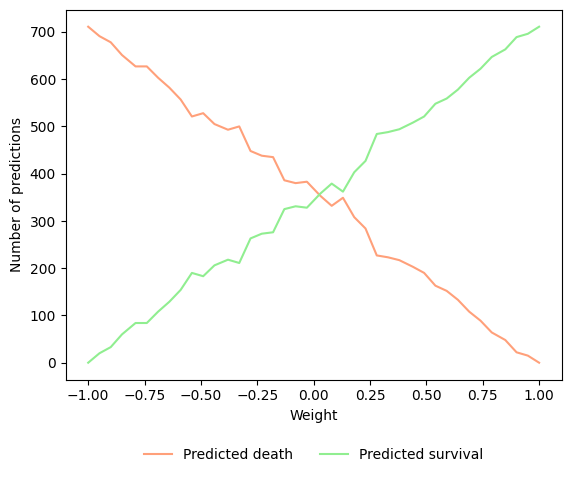

In [27]:
# Plot the distribution of predictions
import matplotlib.pyplot as plt
import matplotlib

# create a graph for the number of predicted deaths
deaths, = plt.plot(
    weights, # point at x-axis
    list(map(lambda cur: l_cm[cur][0][0]+l_cm[cur][1][0], steps)),
    'lightsalmon', # color of the graph
    label='Predicted death'
)

# create a graph for the number of predicted survivals
survivals, = plt.plot(
    weights, # point at x-axis
    list(map(lambda cur: l_cm[cur][0][1]+l_cm[cur][1][1], steps)),
    'lightgreen', # color of the graph
    label='Predicted survival'
)

plt.legend(handles=[deaths, survivals],loc='upper center',
    bbox_to_anchor=(0.5, -0.15), framealpha=0.0, ncol=2)
plt.xlabel("Weight")
plt.ylabel("Number of predictions")

plt.show()

In [28]:
l_precision = list(map(lambda step: precision_score(train_labels, l_predictions[step]),steps))
l_recall = list(map(lambda step: recall_score(train_labels, l_predictions[step]),steps))
l_specificity = list(map(lambda step: specificity(l_cm[step]),steps))
l_npv = list(map(lambda step: npv(l_cm[step]),steps))

/Users/sallyw/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


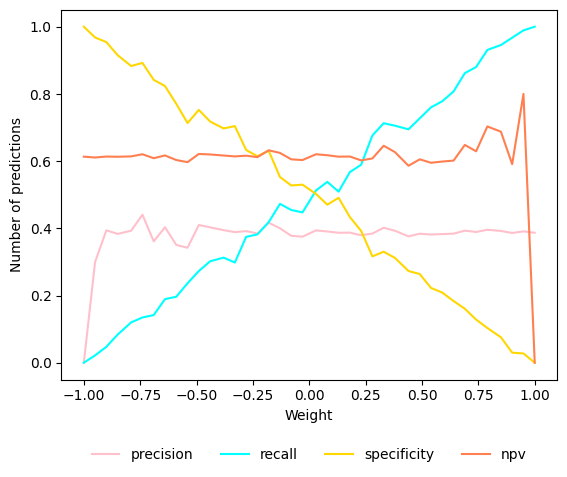

In [30]:
# Plot the performance measures
m_precision, = plt.plot(weights, l_precision, 'pink', label="precision")
m_recall, = plt.plot(weights, l_recall, 'cyan', label="recall")
m_specificity, = plt.plot(weights, l_specificity, 'gold', label="specificity")
m_npv, = plt.plot(weights, l_npv, 'coral', label="npv")

plt.legend(
    handles=[m_precision, m_recall, m_specificity, m_npv],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    framealpha=0.0,
    ncol=4)

plt.xlabel("Weight")
plt.ylabel("Number of predictions")

plt.show()

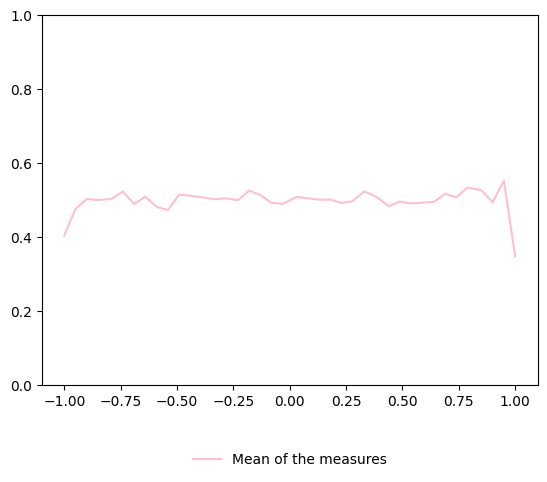

In [31]:
# Calculating the mean of the measures
l_mean = list(map(lambda step: sum(step)*0.25, zip(l_precision, l_recall, l_specificity, l_npv)))
m_mean, = plt.plot(weights, l_mean, 'pink', label="Mean of the measures")

plt.legend(handles=[m_mean],loc='upper center',
    bbox_to_anchor=(0.5, -0.15),framealpha=0.0)
plt.ylim(0, 1)
plt.show()

In [32]:
#A reusable function to unmask the hypocrite classifier
def classifier_report(name, run, classify, input, labels):
    cr_predictions = run(classify, input)
    cr_cm = confusion_matrix(labels, cr_predictions)

    cr_precision = precision_score(labels, cr_predictions, zero_division=0)
    cr_recall = recall_score(labels, cr_predictions)
    cr_specificity = specificity(cr_cm)
    cr_npv = npv(cr_cm)
    cr_level = 0.25*(cr_precision + cr_recall + cr_specificity + cr_npv)

    print('The precision score of the {} classifier is {:.2f}'
        .format(name, cr_precision))
    print('The recall score of the {} classifier is {:.2f}'
        .format(name, cr_recall))
    print('The specificity score of the {} classifier is {:.2f}'
        .format(name, cr_specificity))
    print('The npv score of the {} classifier is {:.2f}'
        .format(name, cr_npv))
    print('The information level is: {:.2f}'
        .format(cr_level))

#The report of the random classifier
classifier_report(
    "Random PQC",
    run,
    classify,
    train_input,
    train_labels)

The precision score of the Random PQC classifier is 0.37
The recall score of the Random PQC classifier is 0.48
The specificity score of the Random PQC classifier is 0.49
The npv score of the Random PQC classifier is 0.60
The information level is: 0.49
